In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [5]:
df=pd.read_csv('C:\\Users\\Diksha\\Desktop\\PROJECTS\\customer_churn_prediction\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Shape:",df.shape)
print("\nColumn info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7043, 21)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

In [7]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

print("Missing after Conversion:",df['TotalCharges'].isnull().sum())

df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges','TotalCharges']]

Missing after Conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [10]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

print("Missing Values Now:", df['TotalCharges'].isnull().sum())

Missing Values Now: 0


<Figure size 800x500 with 0 Axes>

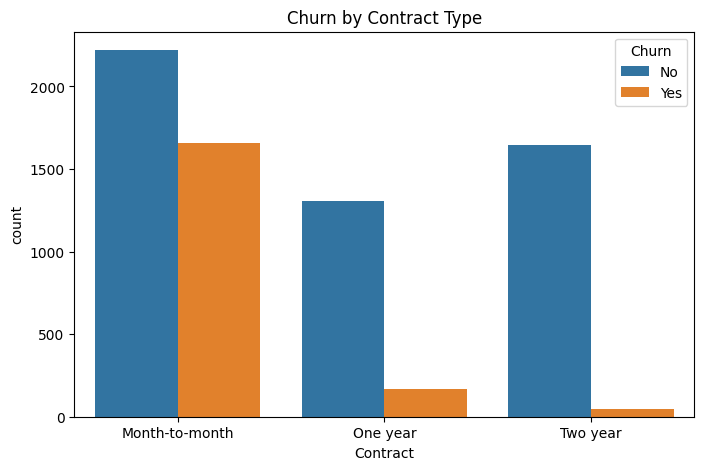

In [13]:
df_model=df.drop('customerID', axis=1)

plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Contract',hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

In [14]:
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
df_model['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [15]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print("\nShape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [16]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Churn rate in train:", y_train.mean())
print("Churn rate in test:", y_test.mean())

Training set shape: (5634, 30)
Test set shape: (1409, 30)
Churn rate in train: 0.2653532126375577
Churn rate in test: 0.2654364797728886


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features - logistic regression performs better with scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506

Confusion Matrix:
[[925 110]
 [162 212]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # Note: tree models don't need scaled data

y_pred_rf = rf.predict(X_test)

print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.7622427253371186
Precision: 0.5387673956262425
Recall: 0.7245989304812834
F1 Score: 0.6180159635119726

Confusion Matrix:
[[803 232]
 [103 271]]


In [22]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight to handle imbalance (similar to class_weight='balanced')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, 
                     scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost Results ===
Accuracy: 0.7558552164655784
Precision: 0.5281954887218046
Recall: 0.7513368983957219
F1 Score: 0.6203090507726269

Confusion Matrix:
[[784 251]
 [ 93 281]]


In [21]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB 960.0 kB/s eta 0:00:51
   ---------------------------------------- 0.5/48.9 MB 5.9 MB/s eta 0:00:09
    --------------------------------------- 1.1/48.9 MB 9.0 MB/s eta 0:00:06
   - -------------------------------------- 1.8/48.9 MB 10.4 MB/s eta 0:00:05
   -- ------------------------------------- 2.5/48.9 MB 11.3 MB/s eta 0:00:05
   -- ------------------------------------- 3.1/48.9 MB 11.7 MB/s eta 0:00:04
   --- ------------------------------------ 3.8/48.9 MB 12.0 MB/s eta 0:00:04
   --- ------------------------------------ 4.4/48.9 MB 12.1 MB/s eta 0:00:04
   ---- ----------------------------------- 5.0/48.9 MB 12.3 MB/s eta 0:00:04
   ---- ----------------------------------- 5.7/48.9 MB 12.6 MB/s eta 0:00:04
   ----- ---------------------------------- 6.2/48.9 MB 12.7 MB/s eta 0:00:04
   ----- ---------------------------------- 6.7/48.9 MB 12.2 MB/s eta 0:0

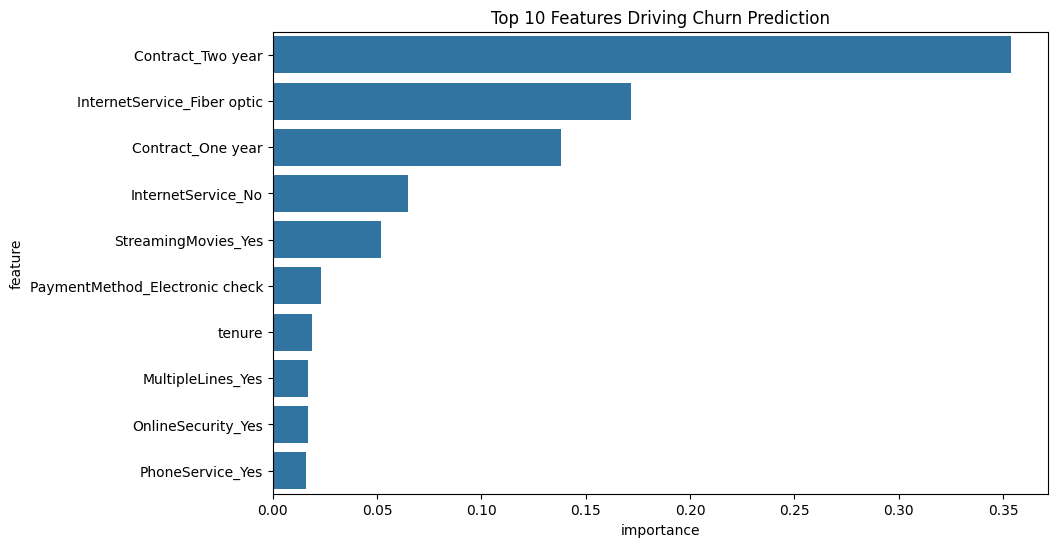

                           feature  importance
25               Contract_Two year    0.353784
10     InternetService_Fiber optic    0.171771
24               Contract_One year    0.138169
11              InternetService_No    0.064925
23             StreamingMovies_Yes    0.051834
28  PaymentMethod_Electronic check    0.023110
1                           tenure    0.018775
9                MultipleLines_Yes    0.016738
13              OnlineSecurity_Yes    0.016644
7                 PhoneService_Yes    0.015855


In [23]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Top 10 Features Driving Churn Prediction')
plt.show()

print(importances)

In [24]:
import joblib

joblib.dump(xgb, 'churn_model.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Model saved successfully")

Model saved successfully
